# EXPLORATORY DATA ANALYSIS OF FINLORA FINANCE DATA
Profile transaction amount, velocity, device novelty, and cross-border
activity by fraud label to see which signals separate fraud from legitimate
activity prior modeling.

### Import Libraries

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import probplot
import os
import joblib
import plotly.express as px
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="whitegrid", rc={
    "font.size": 12, "axes.titlesize": 16, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", None)

# Bold, high-saturation palette used throughout
LEGIT, FRAUD = "#2A6FDB", "#E63946"
ACCENT, ACCENT2 = "#00A896", "#F4A300"
NEUTRAL = "#3D3D3D"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("finlora_bold", [LEGIT, "#F5F1EC", FRAUD])

## Load the Cleaned Finlora Dataset:

In [97]:
# Load finlora data file
finlora_data = pd.read_csv(
    r"C:\Users\User\Documents\AMDARI_IMS\Finlora_Finance_PJ\Dataset\preprocessed_data\cleaned_finlora_data.csv")

# Data Summary
finlora_summary = pd.DataFrame({
    "Data Type": finlora_data.dtypes.astype(str),
    "Missing Values": finlora_data.isna().sum(),
    "% Missing Values": (finlora_data.isna().mean() * 100).round(2),
    "Unique Values": finlora_data.nunique(),
    "Duplicate Values": [finlora_data.duplicated(subset=[col]).sum() for col in finlora_data.columns]
}).sort_values(by="% Missing Values", ascending=False)

finlora_summary

,Data Type,Missing Values,% Missing Values,Unique Values,Duplicate Values
transaction_id,object,0,0.0,126000,0
account_id,object,0,0.0,7144,118856
account_created_date,object,0,0.0,1441,124559
account_holder_name,object,0,0.0,1000,125000
is_refund,int64,0,0.0,2,125998
is_fraud,int64,0,0.0,2,125998
status,object,0,0.0,3,125997
account_age_days,int64,0,0.0,1540,124460
is_new_device,int64,0,0.0,2,125998
device_id,object,0,0.0,14932,111068


### KPIs Overview

In [98]:
fraud_rate = finlora_data['is_fraud'].mean()
print(f"Total transactions: {len(finlora_data):,}")
print(f"Total accounts:     {finlora_data['account_id'].nunique():,}")
print(f"Confirmed fraud:    {finlora_data['is_fraud'].sum():,}")
print(f"Overall fraud rate: {fraud_rate:.2%}")

Total transactions: 126,000
Total accounts:     7,144
Confirmed fraud:    3,352
Overall fraud rate: 2.66%


## Investigating the Project Target Variable

In [99]:
print(finlora_data["is_fraud"].value_counts())
print("="*20)
fraud_distribution = (finlora_data["is_fraud"].value_counts(normalize=True).mul(100).round(2))

print(fraud_distribution)

is_fraud
0    122648
1      3352
Name: count, dtype: int64
is_fraud
0    97.34
1     2.66
Name: proportion, dtype: float64


In [100]:
# Visulization of the target variable
fraud_distribution = (finlora_data["is_fraud"].value_counts(normalize=True).mul(100).round(2).reset_index())

fraud_distribution.columns = ["is_fraud", "proportion"]

# Convert fraud codes to meaningful labels
fraud_distribution["is_fraud"] = fraud_distribution["is_fraud"].map({0: "Legitimate", 1: "Fraud"})

fig = px.sunburst(fraud_distribution, path=["is_fraud"], values="proportion", title="Fraud Distribution")

fig.update_layout(plot_bgcolor="white", paper_bgcolor="white", showlegend=False,  width=800, height=500,)

fig.show()

### Accounting for Outliers

In [101]:
# Checking for outliers in the numerical columns
# Since outliers are only posssible in numerical data, let's analyze the numerical columns
finlora_data.select_dtypes('number').columns.to_list()

['hour_of_day',
 'amount',
 'amount_to_avg_ratio',
 'avg_transaction_amount_30d',
 'transaction_velocity_1h',
 'is_cross_border',
 'is_new_device',
 'account_age_days',
 'is_fraud',
 'is_refund',
 'personal_spend_baseline_usd']

## Accounting for rate of fraud by account type

In [102]:
fraud_by_account = (pd.crosstab(finlora_data["account_type"], finlora_data["is_fraud"], normalize="index") * 100)

print(fraud_by_account)


# Count transactions by fraud status, status and account type
fraud_by_day = (finlora_data.groupby(["is_fraud", "account_type"]).size().reset_index(name="transaction_count"))

# Convert fraud values to readable labels
fraud_by_day["fraud_count"] = fraud_by_day["is_fraud"].map({0: "legitimate", 1: "Fraud"})

# Calculate percentage of total transactions
total_transactions = fraud_by_day["transaction_count"].sum()
fraud_by_day["percentage"] = (fraud_by_day["transaction_count"]/ total_transactions* 100).round(2)

# Create Sunburst chart
fig = px.sunburst(fraud_by_day, path=["fraud_count","account_type"], 
                  values="transaction_count", custom_data=["percentage"], 
                  title="Fraud Distribution by Account Type")

# Display percentage as the label
fig.update_traces(texttemplate="%{label}<br>%{customdata[0]:.2f}%",
    hovertemplate=("<b>%{label}</b><br>""Percentage: %{customdata[0]:.2f}%<br>""Transactions: %{value}<extra></extra>"))

fig.update_layout(plot_bgcolor="white", paper_bgcolor="white",  width=800, height=700, title_font_size=22)

fig.show()

is_fraud              0         1
account_type                     
Business      96.064984  3.935016
Individual    98.020996  1.979004


#### Fraud by KYC Tiers

In [103]:
# groupig the fraud tier
kyc_fraud = (finlora_data.groupby("kyc_tier")["is_fraud"].agg(["count", "sum", "mean"]))

kyc_fraud["fraud_rate_%"] = (kyc_fraud["mean"].round(4)*100)

print(kyc_fraud)  

                count   sum      mean  fraud_rate_%
kyc_tier                                           
Tier1_Basic     22812   742  0.032527          3.25
Tier2_Verified  64094  1750  0.027304          2.73
Tier3_Enhanced  39094   860  0.021998          2.20


In [104]:
# Convert kyc_tier index back into a column
kyc_fraud_plot = (kyc_fraud.reset_index().sort_values("fraud_rate_%", ascending=True))

# Visualizing the Fruad index
fig = px.bar(
    kyc_fraud_plot,
    x="fraud_rate_%",
    y="kyc_tier",
    orientation="h",
    title="Fraud Rate by KYC Tier",
    labels={"fraud_rate_%": "Fraud Rate (%)", "kyc_tier": "KYC Tier"},
    text="fraud_rate_%", custom_data=["count", "sum"], color="fraud_rate_%", color_continuous_scale="reds")

fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside",
                  hovertemplate=("<b>KYC Tier:</b> %{y}<br>""<b>Fraud Rate:</b> %{x:.2f}%<br>"
                   "<b>Total Transactions:</b> %{customdata[0]:,}<br>""<b>Fraud Transactions:</b> %{customdata[1]:,}""<extra></extra>"))

fig.update_layout(plot_bgcolor="white", paper_bgcolor="white", width=1000, height=600, title_font_size=22,

    # Hide numerical horizontal scale
    xaxis=dict(visible=False, showgrid=False, zeroline=False),

    # Keep KYC tier labels
    yaxis=dict(showgrid=False, title=None), margin=dict( l=120, r=100, t=80, b=40))

fig.show()

### Accounting for Fraud by Channel

In [105]:
# check for channels of high fraud rate
channel_fraud = (finlora_data.groupby("channel")["is_fraud"].agg(transactions="count", fraud_cases="sum", fraud_rate="mean"))
channel_fraud["fraud_rate_%"] = (channel_fraud["fraud_rate"].round(4) * 100)
channel_fraud = channel_fraud.sort_values("fraud_rate_%", ascending=False)

print(channel_fraud)

channel_fraud_plot = (channel_fraud.reset_index().sort_values("fraud_rate_%", ascending=True))

# create the plot
fig = px.bar(
    channel_fraud_plot,
    x="fraud_rate_%",
    y="channel",
    orientation="h",
    title="Fraud Rate by Transaction Channel",
    labels={"fraud_rate_%": "Fraud Rate (%)", "channel": "Transaction Channel"},
    text="fraud_rate_%",
    color="fraud_rate_%",
    color_continuous_scale="fall_r")

fig.update_traces(
    texttemplate="%{text:.2f}%", textposition="outside")

fig.update_layout(plot_bgcolor="white", paper_bgcolor="white", width=1000, height=600, title_font_size=22,

    # Hide horizontal scale
    xaxis=dict(visible=False, showgrid=False,  zeroline=False),

    # Keep channel labels
    yaxis=dict(showgrid=False, title=None),

    # Remove colour scale on the right
    coloraxis_showscale=False,

    # Reduce unnecessary margins
    margin=dict(l=120, r=80, t=80, b=40))

fig.show()

                  transactions  fraud_cases  fraud_rate  fraud_rate_%
channel                                                              
API/Integration          13083          477    0.036460          3.65
Web Dashboard            31330          926    0.029556          2.96
Mobile App               41615         1045    0.025111          2.51
Card Not Present         17422          408    0.023419          2.34
Card Present             15080          338    0.022414          2.24
USSD                      7470          158    0.021151          2.12


### Fraud by Merchant Category

In [106]:
merchant_fraud = (finlora_data.groupby("merchant_category")["is_fraud"]
                  .agg(transactions="count", fraud_cases="sum", fraud_rate="mean"))

merchant_fraud["fraud_rate_%"] = (merchant_fraud["fraud_rate"] * 100)

merchant_fraud = merchant_fraud.sort_values("fraud_rate_%",ascending=False)

print(merchant_fraud)


merchant_fraud_plot = (merchant_fraud.reset_index().sort_values("fraud_rate_%", ascending=True))

# create the plot
fig = px.bar(
    merchant_fraud_plot,
    x="fraud_rate_%",
    y="merchant_category",
    orientation="h",
    title="Fraud Rate by Transaction Merchant Category",
    labels={"fraud_rate_%": "Fraud Rate (%)", "merchant_category": "Transaction Merchant Category"},
    text="fraud_rate_%",
    color="fraud_rate_%",
    color_continuous_scale="fall_r")

fig.update_traces(
    texttemplate="%{text:.2f}%", textposition="outside")

fig.update_layout(plot_bgcolor="white", paper_bgcolor="white", width=1000, height=600, title_font_size=22,

    # Hide horizontal scale
    xaxis=dict(visible=False, showgrid=False,  zeroline=False),

    # Keep channel labels
    yaxis=dict(showgrid=False, title=None),

    # Remove colour scale on the right
    coloraxis_showscale=False,

    # Reduce unnecessary margins
    margin=dict(l=120, r=80, t=80, b=40))

fig.show()

                   transactions  fraud_cases  fraud_rate  fraud_rate_%
merchant_category                                                     
Wire Transfer              7639          579    0.075795      7.579526
Payroll Transfer          17117          957    0.055909      5.590933
Crypto Exchange            1692           88    0.052009      5.200946
Travel                     7416          207    0.027913      2.791262
P2P Transfer              10715          272    0.025385      2.538497
Insurance                  4528          106    0.023410      2.340989
Electronics                6173          128    0.020735      2.073546
Gambling/Gaming             951           17    0.017876      1.787592
Utilities                 12444          221    0.017760      1.775956
Healthcare                 4382           69    0.015746      1.574623
Retail                    13742          203    0.014772      1.477223
ATM Withdrawal             5129           74    0.014428      1.442776
Subscr

### Fraud by Cross-border Status

In [107]:
cross_border = (finlora_data.groupby("is_cross_border")["is_fraud"]
                .agg(transactions="count", fraud_cases="sum", fraud_rate="mean"))

cross_border["fraud_rate_%"] = (cross_border["fraud_rate"] * 100)

print(cross_border)


# Create transaction-level groups for the Sunburst
cross_border_plot = (finlora_data.groupby(["is_cross_border", "is_fraud"], dropna=False).size().reset_index(name="Transaction_Count"))


# # Create readable labels
# cross_border_plot = finlora_data.copy()

cross_border_plot["Cross_Border_Status"] = (cross_border_plot["is_cross_border"].map({0: "Domestic", 1: "Cross-Border"}))

cross_border_plot["Fraud_Status"] = (cross_border_plot["is_fraud"].map({0: "Legitimate", 1: "Fraud"}))

# Group transactions
cross_border_plot["Total_Transactions"] = (cross_border_plot.groupby("Cross_Border_Status")["Transaction_Count"].transform("sum"))


# Calculate percentage of all transactions
cross_border_plot["Percentage"] = (cross_border_plot["Transaction_Count"]/ cross_border_plot["Total_Transactions"]* 100).round(2)

# Create Sunburst chart
fig = px.sunburst(cross_border_plot, 
                  path=["Cross_Border_Status", "Fraud_Status"],
                  values="Transaction_Count",
                  custom_data=["Percentage"], 
                  title="Fraud Distribution by Cross-Border Transactions")

# Display percentage and transaction count
fig.update_traces(texttemplate="%{label}<br>%{customdata[0]:.2f}%",
                  customdata=cross_border_plot[["Percentage"]],
                  hovertemplate=("<b>%{label}</b><br>""Transactions: %{value:,}<br>""Percentage: %{customdata[0]:.2f}%""<extra></extra>"))

fig.update_layout(plot_bgcolor="white", paper_bgcolor="white", width=900, height=700, title_font_size=22)

fig.show()

                 transactions  fraud_cases  fraud_rate  fraud_rate_%
is_cross_border                                                     
0                      123455         3265    0.026447      2.644688
1                        2545           87    0.034185      3.418468


### Fraud by New Device

In [108]:
device_fraud = (
    finlora_data.groupby("is_new_device", dropna=False)["is_fraud"]
    .agg(
        transactions="count",
        fraud_cases="sum",
        fraud_rate="mean"
    )
)

device_fraud["fraud_rate_%"] = (
    device_fraud["fraud_rate"] * 100
)

print(device_fraud)


# Group fraud transactions by device status 
device_fraud = (finlora_data.groupby(["is_new_device", "is_fraud"],
                                              dropna=False).size().reset_index(name="transaction_count"))

# Convert device values into readable labels
device_fraud["device_status"] = (device_fraud["is_new_device"] .map({0: "Existing Device", 1: "New Device"}).fillna("Unknown"))

# Convert fraud values into readable labels
device_fraud["fraud_status"] = (device_fraud["is_fraud"].map({0: "Legitimate", 1: "Fraud"}).fillna("Unknown"))

# Calculate total transactions within each device group
device_fraud["group_total"] = (device_fraud.groupby("device_status")["transaction_count"].transform("sum"))

# Calculate percentage of fraud within each device group
device_fraud["fraud_percentage"] = (device_fraud["transaction_count"]/ device_fraud["group_total"]* 100).round(2)

# Create Sunburst
fig = px.sunburst(device_fraud,  path=["device_status", "fraud_status"], values="transaction_count", 
                  custom_data=["fraud_percentage"], title="Fraud Distribution by Device Status")


# Display percentage and transaction count
fig.update_traces(texttemplate="%{label}<br>%{customdata[0]:.2f}%",
                  customdata=device_fraud[["fraud_percentage"]],
                  hovertemplate=("<b>%{label}</b><br>""Transactions: %{value:,}<br>""Percentage: %{customdata[0]:.2f}%""<extra></extra>"))

fig.update_layout(plot_bgcolor="white", paper_bgcolor="white", width=800, height=700, title_font_size=22)

fig.show()

               transactions  fraud_cases  fraud_rate  fraud_rate_%
is_new_device                                                     
0                    122105         3124    0.025585      2.558454
1                      3895          228    0.058537      5.853659


### Fraud by Transaction Velocity

In [109]:
# Create readable fraud labels
velocity_plot = finlora_data.copy()

velocity_plot["Fraud_Status"] = (velocity_plot["is_fraud"].map({0: "Legitimate", 1: "Fraud"}))

# Create boxplot
fig = px.box(velocity_plot, x="Fraud_Status", y="transaction_velocity_1h", title="Transaction Velocity by Fraud Status",
    labels={"Fraud_Status": "Fraud Status", "transaction_velocity_1h": "Transactions in Previous 1 Hour"}, points="outliers")

# Formatting
fig.update_layout(plot_bgcolor="white", paper_bgcolor="white", width=900, height=600, title_font_size=22,

    xaxis=dict(showgrid=False, showline=True, title="Fraud Status"),
    yaxis=dict(showgrid=False, showline=True, title="Transactions in Previous 1 Hour"))

fig.show()

is_fraud
0    97.34
1     2.66
Name: proportion, dtype: float64


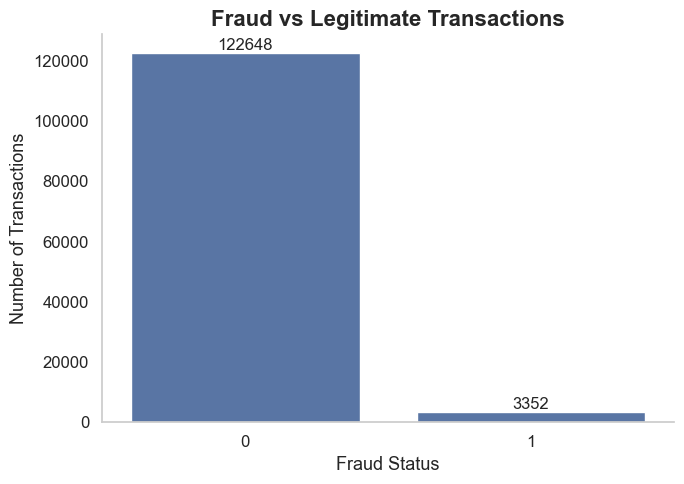

In [122]:
fraud_distribution = (
    finlora_data["is_fraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(fraud_distribution)

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data= finlora_data,
    x="is_fraud"
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container)

ax.grid(False)
# Remove top and right borders
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
plt.tight_layout()
plt.show()

### Fraud by Transaction base line

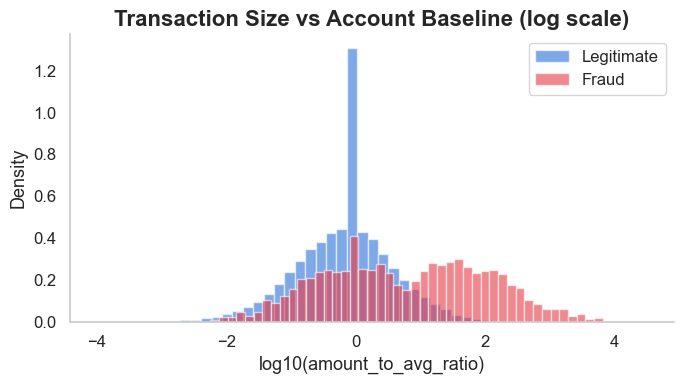

Mean amount_to_avg_ratio -- Fraud: 152.61x  |  Legitimate: 3.99x


In [121]:
finlora_data['is_fraud_lbl'] = finlora_data['is_fraud'].map({0: 'Legitimate', 1: 'Fraud'})
PALETTE = {'Legitimate': "#2A6FDB", 'Fraud': "#E63946"}

def fraud_rate_bar(col, title, top_n=None, rot=0, figsize=(7,4)):
    g = df.groupby(col)['is_fraud'].agg(['mean','count']).reset_index().sort_values('mean', ascending=False)
    if top_n: g = g.head(top_n)
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(g[col].astype(str), g['mean']*100, color='#C44E52')
    ax.axhline(fraud_rate*100, color='gray', linestyle='--', linewidth=1, label='Overall rate')
    ax.set_ylabel('Fraud rate (%)'); ax.set_title(title); ax.legend()
    plt.xticks(rotation=rot, ha='right' if rot else 'center')
    plt.tight_layout(); plt.show()
    return g

fig, ax = plt.subplots(figsize=(7,4))
for lbl, color in PALETTE.items():
    vals = finlora_data.loc[finlora_data['is_fraud_lbl']==lbl, 'amount_to_avg_ratio']
    vals = vals[vals > 0]
    ax.hist(np.log10(vals + 1e-6), bins=50, alpha=0.6, label=lbl, color=color, density=True)
ax.set_xlabel('log10(amount_to_avg_ratio)'); ax.set_ylabel('Density')
ax.set_title('Transaction Size vs Account Baseline (log scale)')
ax.grid(False)
# Remove top and right borders
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
ax.legend(); plt.tight_layout(); plt.show()

print(f"Mean amount_to_avg_ratio -- Fraud: {finlora_data.loc[finlora_data.is_fraud==1,'amount_to_avg_ratio'].mean():.2f}x  |  Legitimate: {finlora_data.loc[finlora_data.is_fraud==0,'amount_to_avg_ratio'].mean():.2f}x")


### Numerical Corrections to Fraudulent transactions

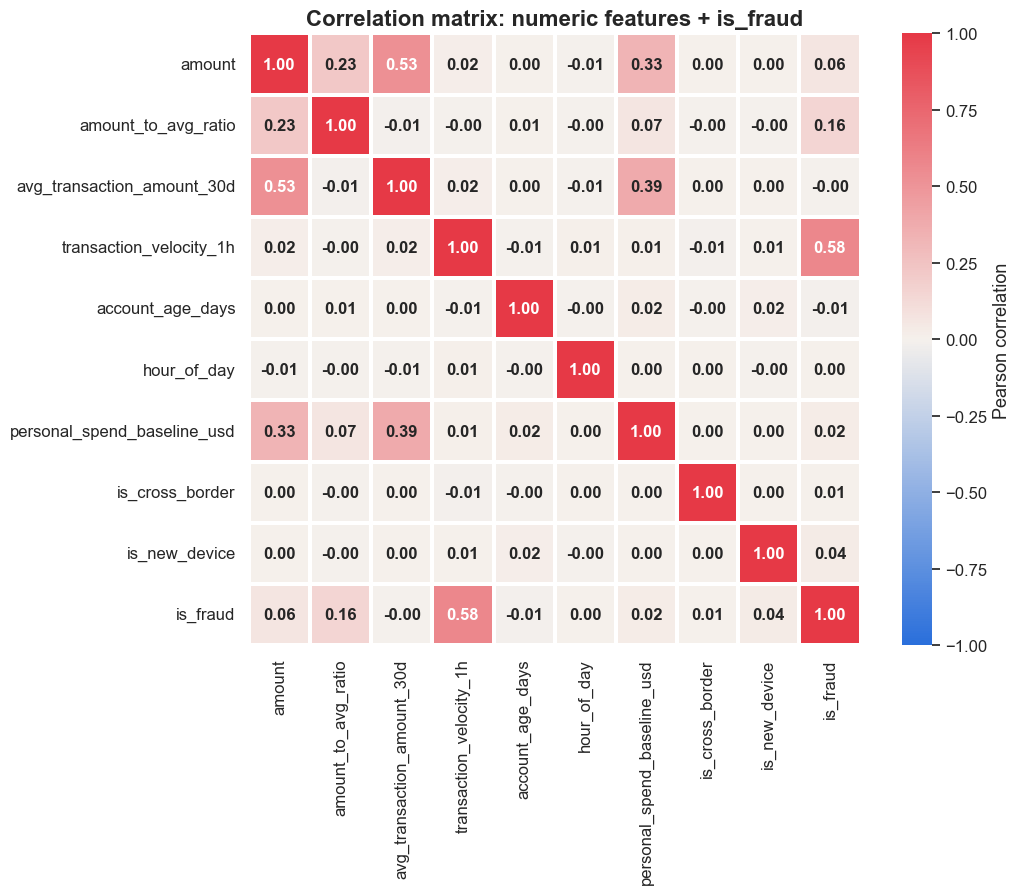

transaction_velocity_1h        0.577002
amount_to_avg_ratio            0.155696
amount                         0.063006
is_new_device                  0.035442
personal_spend_baseline_usd    0.024793
account_age_days              -0.013157
is_cross_border                0.006764
hour_of_day                    0.003477
avg_transaction_amount_30d    -0.001767
Name: is_fraud, dtype: float64

In [112]:
corr_cols = [
    "amount", "amount_to_avg_ratio", "avg_transaction_amount_30d", "transaction_velocity_1h",
    "account_age_days", "hour_of_day", "personal_spend_baseline_usd", "is_cross_border",
]
corr_data = finlora_data[corr_cols].copy()
corr_data["is_new_device"] = finlora_data["is_new_device"]
corr_data["is_fraud"] = finlora_data["is_fraud"]
corr = corr_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0, vmin=-1, vmax=1,
    linewidths=1.5, linecolor="white", square=True, ax=ax,
    annot_kws={"fontweight": "bold", "fontsize": 12},
    cbar_kws={"label": "Pearson correlation"},
)
ax.set_title("Correlation matrix: numeric features + is_fraud")
ax.tick_params(labelsize=12)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Pearson correlation", fontsize=13)
plt.tight_layout()
plt.show()

corr["is_fraud"].drop("is_fraud").sort_values(key=abs, ascending=False)

### Hourly Fraud Rate

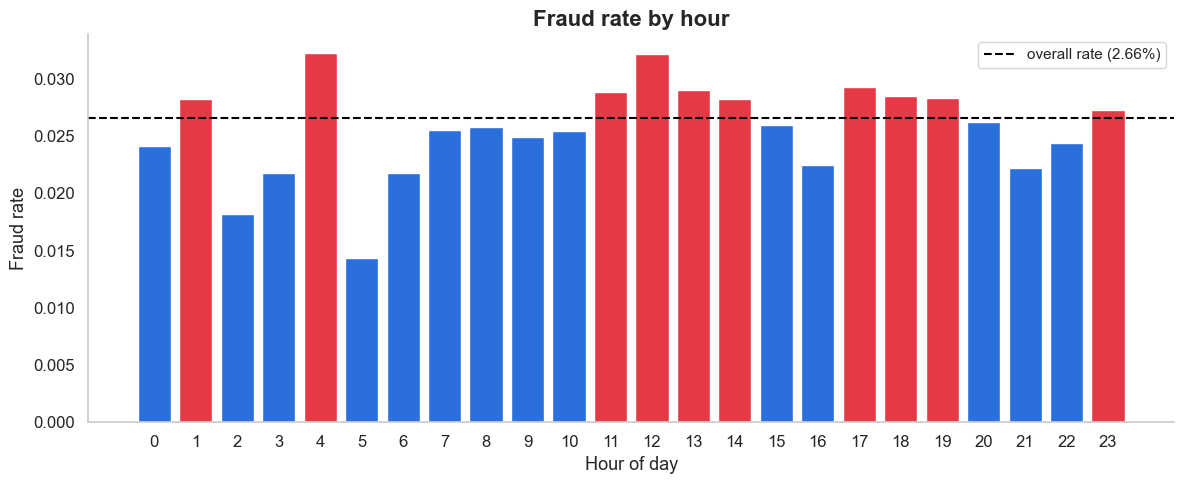

In [ ]:
fraud_rate = finlora_data["is_fraud"].mean()
rates = finlora_data.groupby("hour_of_day")["is_fraud"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = [FRAUD if v >= fraud_rate else LEGIT for v in rates.values]
ax.bar(rates.index.astype(str), rates.values, color=colors)
ax.axhline(fraud_rate, color="black", linestyle="--", linewidth=1.5,
           label=f"overall rate ({fraud_rate:.2%})")
ax.set_title("Fraud rate by hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraud rate")
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.legend(fontsize=11)
ax.grid(False)

# Remove top and right borders
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
plt.tight_layout()
plt.show()

### Fraud rate by Is Weekdays

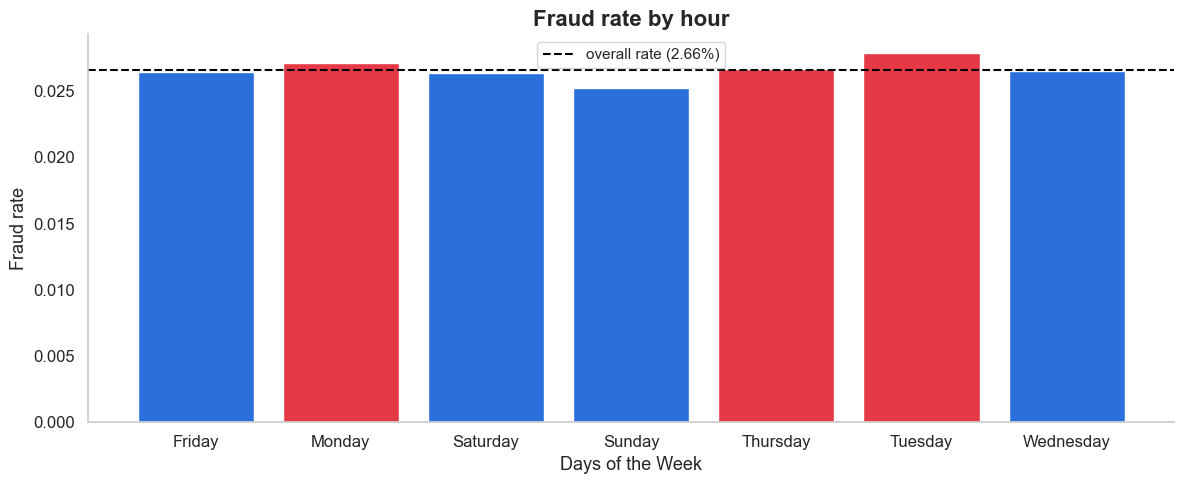

In [ ]:
fraud_rate = finlora_data["is_fraud"].mean()
rates = finlora_data.groupby("day_of_week")["is_fraud"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = [FRAUD if v >= fraud_rate else LEGIT for v in rates.values]
ax.bar(rates.index.astype(str), rates.values, color=colors)
ax.axhline(fraud_rate, color="black", linestyle="--", linewidth=1.5,
           label=f"overall rate ({fraud_rate:.2%})")
ax.set_title("Fraud rate by hour")
ax.set_xlabel("Days of the Week")
ax.set_ylabel("Fraud rate")
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.legend(fontsize=11)
ax.grid(False)

# Remove top and right borders
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
plt.tight_layout()
plt.show()

`Summary:` the data shows majority of fraudulent transaction to occur during working days of the week. however in terms of the entire datset percent fraudulent activity still remains low.